# Convolutional Neural Network – MNIST

This program implements a Convolutional Neural Network (CNN) to classify handwritten digits using the MNIST dataset.

**MNIST Dataset:**
- 70,000 grayscale images of handwritten digits (0–9)
- Image size: 28x28 pixels
- Training images: 60,000
- Testing images: 10,000

In [1]:
# ===============================
# Import Required Libraries
# ===============================

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

c:\Users\Yugesh\anaconda3\envs\tf_gpu_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
c:\Users\Yugesh\anaconda3\envs\tf_gpu_env\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


## About MNIST Dataset

Each image is a $28 \times 28$ grayscale image.
Pixel values range from 0 to 255.

**Why normalize pixel values?**
- Large values slow down training
- Neural networks work better with small numbers

**Normalization formula:**
`normalized_pixel = pixel_value / 255`

After normalization: Pixel values range from `[0, 1]`

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape to include channel dimension
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

## One-Hot Encode Labels

Labels are digits (0–9). This is required for softmax classification.

**Example:**
Digit 5 → `[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]`

In [3]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

## Visualize the Dataset
Let's look at the first 25 images from the training set.

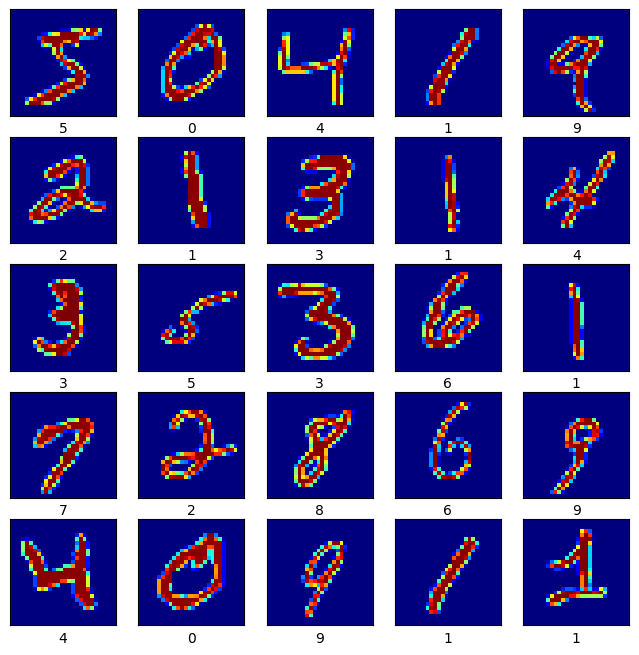

In [4]:
plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i].reshape(28, 28), cmap='jet')
    plt.xlabel(np.argmax(y_train[i]))
plt.show()

## Build the Convolutional Neural Network


In [5]:
model = models.Sequential([
    # First Convolution Layer
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    # Reduces spatial dimensions
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Second Convolution Layer
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu'
    ),
    # Second Pooling Layer
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Converts 2D feature maps to 1D vector
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(64, activation='relu'),

    # Output Layer (10 digits)
    layers.Dense(10, activation='softmax')
])

## Compile and Train the Model

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'] 
)

model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_test, y_test) 
)

Epoch 1/5
938/938 [==============================] - 15s 5ms/step - loss: 0.1720 - accuracy: 0.9491 - val_loss: 0.0470 - val_accuracy: 0.9855
Epoch 2/5
938/938 [==============================] - 4s 5ms/step - loss: 0.0504 - accuracy: 0.9845 - val_loss: 0.0342 - val_accuracy: 0.9885
Epoch 3/5
938/938 [==============================] - 4s 4ms/step - loss: 0.0348 - accuracy: 0.9892 - val_loss: 0.0337 - val_accuracy: 0.9880
Epoch 4/5
938/938 [==============================] - 4s 4ms/step - loss: 0.0263 - accuracy: 0.9916 - val_loss: 0.0295 - val_accuracy: 0.9904
Epoch 5/5
938/938 [==============================] - 4s 4ms/step - loss: 0.0197 - accuracy: 0.9937 - val_loss: 0.0291 - val_accuracy: 0.9906


## Evaluate Model Accuracy

In [7]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

313/313 [==============================] - 1s 2ms/step - loss: 0.0291 - accuracy: 0.9906
Test Accuracy: 0.99


## Test with Single Predictions

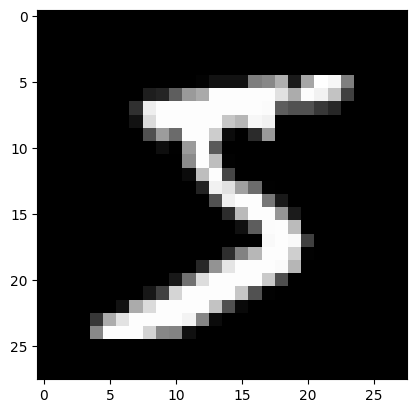

1/1 [==============================] - 0s 116ms/step


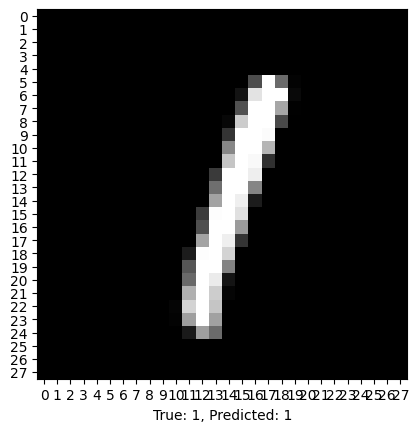

In [8]:
def predict_single_image(index):
    image = x_test[index]
    true_label = np.argmax(y_test[index])

    prediction = model.predict(image.reshape(1, 28, 28, 1))
    predicted_label = np.argmax(prediction)

    plt.imshow(image.reshape(28, 28), cmap='gray')
    plt.xticks(np.arange(28))
    plt.yticks(np.arange(28))
    plt.xlabel(f"True: {true_label}, Predicted: {predicted_label}")
    plt.show()

# Show the first image from the train set as a test
plt.imshow(x_train[0].reshape(28,28), cmap='gray')
plt.show()

# Predict the 6th image (index 5) in the test set
predict_single_image(5)